<div align="center">

# **Olist Revenue Intelligence — Late Delivery Modeling**

### Classification modeling for order-level late delivery risk prediction

</div>

## 1. Notebook Objective

The objective of this notebook is to train and evaluate classification models for **late delivery prediction** at the order level.

This notebook uses the clean modeling dataset produced in the previous step and focuses on the following tasks:

- loading the final modeling dataset
- defining the predictive inputs and target
- preparing the data for machine learning
- training baseline and non-linear classification models
- evaluating model performance with metrics adapted to class imbalance
- interpreting the results from a business perspective

This notebook extends the Revenue Intelligence project from:
- **diagnostic analytics**
to
- **predictive operational support**

## 2. Modeling Framing

### Predictive task

The modeling task is a binary classification problem:

- `is_late = 1` if the order is delivered later than its estimated delivery timestamp
- `is_late = 0` otherwise

### Modeling scope

The dataset is restricted to delivered orders with observable delivery outcome.  
The predictive objective is therefore not to model the full order lifecycle, but to estimate **late-delivery risk** within the delivered-order population.

### Modeling logic

The selected feature set remains intentionally compact and business-oriented. It includes:

- order structure signals
- purchase-time temporal signals
- customer geography
- estimated delivery horizon

This first modeling version prioritizes:
- methodological clarity
- leakage control
- interpretability
- defensible baseline performance

In [1]:
# ============================================================
# 0. Imports and setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

## 3. Load the Final Modeling Dataset

The modeling dataset used here was exported from the previous notebook after:
- feature construction
- target validation
- leakage audit
- final cleanup

The first step is therefore to reload that dataset and verify that the expected structure is present before building the modeling pipeline.

In [2]:
# ============================================================
# 1. Load modeling dataset
# ============================================================

DATA_PATH = Path("../data/processed/late_delivery_modeling_dataset.csv")

df_model = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_model.shape)
print("\nColumns:")
display(pd.DataFrame({"column": df_model.columns}))

Dataset shape: (96470, 13)

Columns:


,column
0,order_id
1,is_late
2,order_revenue
3,n_items
4,n_sellers
5,n_categories
6,customer_state
7,estimated_delivery_days
8,purchase_month
9,purchase_dayofweek


In [3]:
display(df_model.head())

,order_id,is_late,order_revenue,n_items,n_sellers,n_categories,customer_state,estimated_delivery_days,purchase_month,purchase_dayofweek,purchase_hour,is_weekend,order_revenue_per_item
0,e481f51cbdc54678b7cc49136f2d6af7,0,38.71,1,1,1,SP,15.544063,10,0,10,0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,0,141.46,1,1,1,BA,19.137766,7,1,20,0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,0,179.12,1,1,1,GO,26.639711,8,2,8,0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,0,72.20,1,1,1,RN,26.188819,11,5,19,1,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,0,28.62,1,1,1,SP,12.112049,2,1,21,0,28.62


In [4]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 96470 non-null  str    
 1   is_late                  96470 non-null  int64  
 2   order_revenue            96470 non-null  float64
 3   n_items                  96470 non-null  int64  
 4   n_sellers                96470 non-null  int64  
 5   n_categories             96470 non-null  int64  
 6   customer_state           96470 non-null  str    
 7   estimated_delivery_days  96470 non-null  float64
 8   purchase_month           96470 non-null  int64  
 9   purchase_dayofweek       96470 non-null  int64  
 10  purchase_hour            96470 non-null  int64  
 11  is_weekend               96470 non-null  int64  
 12  order_revenue_per_item   96470 non-null  float64
dtypes: float64(3), int64(8), str(2)
memory usage: 12.7 MB


## 4. Validate Modeling Inputs

Before defining the modeling pipeline, the dataset must be checked for basic consistency:

- one row should still correspond to one order
- the target should be present
- the expected feature columns should exist
- the class distribution should remain unchanged after reload

In [5]:
# ============================================================
# 2. Validate modeling inputs
# ============================================================

print("Number of rows:", len(df_model))
print("Number of unique order_id:", df_model["order_id"].nunique())
print("Rows == unique orders?", len(df_model) == df_model["order_id"].nunique())

Number of rows: 96470
Number of unique order_id: 96470
Rows == unique orders? True


In [6]:
expected_columns = [
    "order_id",
    "is_late",
    "order_revenue",
    "n_items",
    "n_sellers",
    "n_categories",
    "customer_state",
    "estimated_delivery_days",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "is_weekend",
    "order_revenue_per_item"
]

missing_columns = [col for col in expected_columns if col not in df_model.columns]
unexpected_columns = [col for col in df_model.columns if col not in expected_columns]

print("Missing expected columns:", missing_columns)
print("Unexpected columns:", unexpected_columns)

Missing expected columns: []
Unexpected columns: []


In [7]:
target_distribution = (
    df_model["is_late"]
    .value_counts(dropna=False)
    .rename_axis("is_late")
    .reset_index(name="count")
)

target_distribution["share"] = target_distribution["count"] / target_distribution["count"].sum()

display(target_distribution)
print(f"\nLate delivery rate: {df_model['is_late'].mean():.2%}")

,is_late,count,share
0,0,88644,0.918876
1,1,7826,0.081124



Late delivery rate: 8.11%


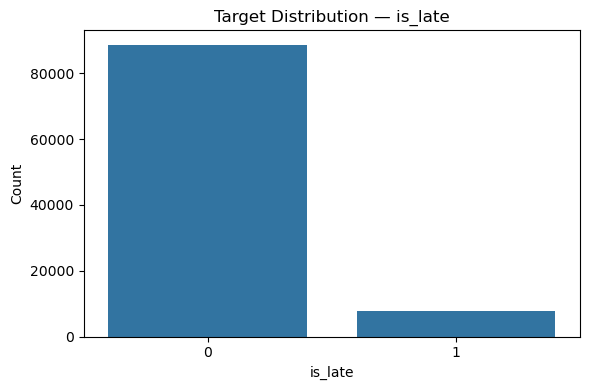

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_model, x="is_late")
plt.title("Target Distribution — is_late")
plt.xlabel("is_late")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Modeling input validation result

The exported modeling dataset was successfully reloaded with the exact expected structure.

The order-level grain is preserved, with one row per `order_id`, and the full V1 feature set is available without missing or unexpected columns.

The target distribution remains unchanged after reload, confirming that late deliveries still represent a minority class at roughly 8% of the population. This confirms the need to evaluate the models with metrics adapted to class imbalance rather than relying on accuracy alone.

The feature matrix is now cleanly separated from the target, with a combination of numerical and categorical predictors suitable for a preprocessing pipeline.)

## 5. Define Feature Matrix and Target

The next step is to separate:
- the target variable (`y`)
- the predictive features (`X`)
- the identifier column, which must not be used as model input

At this stage, no preprocessing is applied yet.  
The objective is only to define the modeling inputs clearly.

In [9]:
# ============================================================
# 3. Define X and y
# ============================================================

id_column = "order_id"
target_column = "is_late"

feature_columns = [
    "order_revenue",
    "n_items",
    "n_sellers",
    "n_categories",
    "customer_state",
    "estimated_delivery_days",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "is_weekend",
    "order_revenue_per_item"
]

X = df_model[feature_columns].copy()
y = df_model[target_column].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96470, 11)
y shape: (96470,)


In [10]:
print("Feature dtypes:")
display(X.dtypes.to_frame("dtype"))

Feature dtypes:


,dtype
order_revenue,float64
n_items,int64
n_sellers,int64
n_categories,int64
customer_state,str
estimated_delivery_days,float64
purchase_month,int64
purchase_dayofweek,int64
purchase_hour,int64
is_weekend,int64


In [11]:
print("Target distribution in y:")
display(y.value_counts(normalize=False).to_frame("count"))
display(y.value_counts(normalize=True).to_frame("share"))

Target distribution in y:


,count
is_late,
0,88644
1,7826


,share
is_late,
0,0.918876
1,0.081124


## End of Block 1

The modeling dataset is now loaded and validated.

At this stage, we have:
- a confirmed order-level modeling table
- a validated target variable
- a predefined V1 feature set
- a clean separation between `X` and `y`

The next step will be to define the train/test strategy and set up the preprocessing pipeline.

## 6. Train/Test Strategy

The next step is to define a train/test split for model evaluation.

For this first modeling version, a stratified random split is used in order to:
- preserve the target class distribution in both sets
- obtain a stable and interpretable baseline comparison across models

A time-based split could be considered in a more advanced version, but the priority here is to establish a clean and defensible V1 modeling benchmark.

In [12]:
# ============================================================
# 4. Modeling utilities
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [13]:
# ============================================================
# 5. Train/test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (77176, 11)
X_test shape : (19294, 11)
y_train shape: (77176,)
y_test shape : (19294,)


In [14]:
train_target_dist = y_train.value_counts(normalize=True).rename("share_train").to_frame()
test_target_dist = y_test.value_counts(normalize=True).rename("share_test").to_frame()

display(train_target_dist)
display(test_target_dist)

,share_train
is_late,
0,0.918874
1,0.081126


,share_test
is_late,
0,0.918887
1,0.081113


## 7. Define Numerical and Categorical Features

The V1 feature set contains:
- one categorical feature: `customer_state`
- several numerical features related to order structure, timing and delivery horizon

This distinction is necessary in order to build a preprocessing pipeline that:
- encodes categorical variables
- scales numerical variables when appropriate
- applies transformations consistently across train and test sets

In [15]:
# ============================================================
# 6. Feature groups
# ============================================================

categorical_features = ["customer_state"]

numerical_features = [
    "order_revenue",
    "n_items",
    "n_sellers",
    "n_categories",
    "estimated_delivery_days",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "is_weekend",
    "order_revenue_per_item"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['customer_state']
Numerical features: ['order_revenue', 'n_items', 'n_sellers', 'n_categories', 'estimated_delivery_days', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'is_weekend', 'order_revenue_per_item']


In [16]:
missing_categorical = [col for col in categorical_features if col not in X_train.columns]
missing_numerical = [col for col in numerical_features if col not in X_train.columns]

print("Missing categorical features:", missing_categorical)
print("Missing numerical features:", missing_numerical)

Missing categorical features: []
Missing numerical features: []


## 8. Build the Preprocessing Pipeline

The preprocessing logic must remain aligned with the nature of the models.

For the baseline Logistic Regression model:
- categorical variables will be one-hot encoded
- numerical variables will be standardized

This creates a clean and reproducible transformation pipeline that can later be reused consistently across models.

In [17]:
# ============================================================
# 7. Preprocessing pipeline for logistic regression
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print(preprocessor_lr)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['order_revenue', 'n_items', 'n_sellers',
                                  'n_categories', 'estimated_delivery_days',
                                  'purchase_month', 'purchase_dayofweek',
                                  'purchase_hour', 'is_weekend',
                                  'order_revenue_per_item']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['customer_state'])])


In [18]:
# Fit preprocessing pipeline on train set only
X_train_preprocessed = preprocessor_lr.fit_transform(X_train)
X_test_preprocessed = preprocessor_lr.transform(X_test)

print("Preprocessed X_train shape:", X_train_preprocessed.shape)
print("Preprocessed X_test shape :", X_test_preprocessed.shape)

Preprocessed X_train shape: (77176, 37)
Preprocessed X_test shape : (19294, 37)


### Train/test split and preprocessing validation result

The train/test split was successfully created with stratification on the target variable.

The class distribution remains virtually identical across the training and test sets, which confirms that the split preserves the original class imbalance and provides a reliable basis for model comparison.

The feature groups are correctly specified:
- one categorical feature (`customer_state`)
- ten numerical features related to order structure, timing and estimated delivery horizon

The preprocessing pipeline also runs correctly:
- numerical variables are standardized
- the categorical variable is one-hot encoded with safe handling of unseen categories

The transformed design matrices are fully consistent across train and test sets, which means the modeling pipeline is now ready for the first baseline classifier.

## End of Block 2

The modeling workflow now has:
- a stratified train/test split
- validated numerical and categorical feature groups
- a reproducible preprocessing pipeline for the baseline classifier

The next step is to train and evaluate the first model: Logistic Regression.

## 9. Baseline Model — Logistic Regression

The first model is a Logistic Regression classifier.

This model is used as the baseline because it offers:
- interpretability
- robustness
- a strong benchmark for tabular binary classification

Given the class imbalance, class weighting is introduced so that the minority class receives more importance during training.

In [19]:
# ============================================================
# 8. Logistic Regression baseline
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [20]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    ))
])

lr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [21]:
lr_pipeline.fit(X_train, y_train)
print("Logistic Regression model fitted successfully.")

Logistic Regression model fitted successfully.


In [22]:
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print("Predicted positive rate:", y_pred_lr.mean())

Predictions generated.
Predicted positive rate: 0.39302373794962164


In [23]:
lr_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "recall": recall_score(y_test, y_pred_lr, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_lr, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_lr),
    "pr_auc": average_precision_score(y_test, y_proba_lr)
}

lr_metrics_df = pd.DataFrame.from_dict(lr_metrics, orient="index", columns=["value"])
display(lr_metrics_df)

,value
accuracy,0.629107
precision,0.131346
recall,0.636422
f1_score,0.217753
roc_auc,0.686273
pr_auc,0.162393


In [24]:
print("Classification Report — Logistic Regression\n")
print(classification_report(y_test, y_pred_lr, digits=4, zero_division=0))

Classification Report — Logistic Regression

              precision    recall  f1-score   support

           0     0.9514    0.6285    0.7569     17729
           1     0.1313    0.6364    0.2178      1565

    accuracy                         0.6291     19294
   macro avg     0.5414    0.6324    0.4873     19294
weighted avg     0.8849    0.6291    0.7132     19294



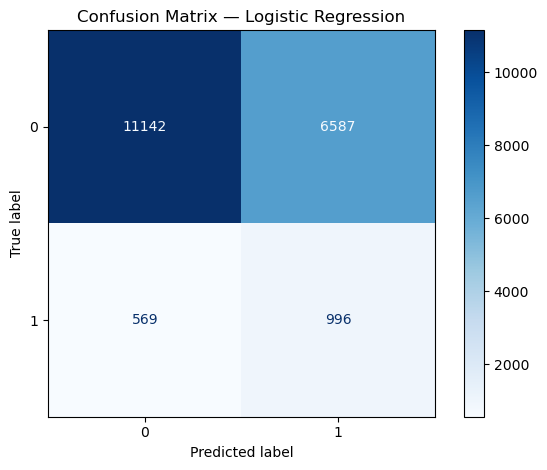

In [25]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

In [26]:
cm_lr_df = pd.DataFrame(
    cm_lr,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_lr_df)

,Predicted 0,Predicted 1
Actual 0,11142,6587
Actual 1,569,996


In [27]:
actual_positive_rate = y_test.mean()
predicted_positive_rate = y_pred_lr.mean()

comparison_df = pd.DataFrame({
    "metric": ["actual_positive_rate", "predicted_positive_rate"],
    "value": [actual_positive_rate, predicted_positive_rate]
})

display(comparison_df)

,metric,value
0,actual_positive_rate,0.081113
1,predicted_positive_rate,0.393024


In [28]:
# Recover transformed feature names
feature_names_num = numerical_features

ohe = lr_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = ohe.get_feature_names_out(categorical_features).tolist()

all_feature_names = feature_names_num + feature_names_cat

coefficients = lr_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
}).sort_values("abs_coefficient", ascending=False)

display(coef_df.head(20))

,feature,coefficient,abs_coefficient
35,customer_state_SP,-1.426860,1.426860
31,customer_state_RR,1.279298,1.279298
11,customer_state_AL,1.259870,1.259870
27,customer_state_PR,-1.201805,1.201805
20,customer_state_MG,-1.032180,1.032180
19,customer_state_MA,0.855170,0.855170
23,customer_state_PA,0.803536,0.803536
30,customer_state_RO,-0.775425,0.775425
16,customer_state_DF,-0.760984,0.760984
4,estimated_delivery_days,-0.671332,0.671332


In [29]:
top_positive = coef_df.sort_values("coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("coefficient", ascending=True).head(10)

print("Top positive coefficients:")
display(top_positive[["feature", "coefficient"]])

print("Top negative coefficients:")
display(top_negative[["feature", "coefficient"]])

Top positive coefficients:


,feature,coefficient
31,customer_state_RR,1.279298
11,customer_state_AL,1.259870
19,customer_state_MA,0.855170
23,customer_state_PA,0.803536
15,customer_state_CE,0.609111
34,customer_state_SE,0.539386
26,customer_state_PI,0.420231
13,customer_state_AP,0.376395
24,customer_state_PB,0.370208
14,customer_state_BA,0.338080


Top negative coefficients:


,feature,coefficient
35,customer_state_SP,-1.426860
27,customer_state_PR,-1.201805
20,customer_state_MG,-1.032180
30,customer_state_RO,-0.775425
16,customer_state_DF,-0.760984
4,estimated_delivery_days,-0.671332
32,customer_state_RS,-0.424723
18,customer_state_GO,-0.410680
10,customer_state_AC,-0.345173
22,customer_state_MT,-0.292097


### Threshold Sensitivity Check

The default classification threshold of 0.5 may not be optimal in an imbalanced setting, especially when class weighting is used.

This section evaluates how the Logistic Regression model behaves under different probability thresholds in order to better understand the trade-off between:
- precision
- recall
- F1-score
- predicted positive rate

In [30]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for thr in thresholds:
    y_pred_thr = (y_proba_lr >= thr).astype(int)
    
    threshold_results.append({
        "threshold": thr,
        "accuracy": accuracy_score(y_test, y_pred_thr),
        "precision": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall": recall_score(y_test, y_pred_thr, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_thr, zero_division=0),
        "predicted_positive_rate": y_pred_thr.mean()
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,threshold,accuracy,precision,recall,f1_score,predicted_positive_rate
0,0.3,0.239401,0.092300,0.948243,0.168225,0.833316
1,0.4,0.437597,0.109307,0.830032,0.193174,0.615943
2,0.5,0.629107,0.131346,0.636422,0.217753,0.393024
3,0.6,0.785944,0.168176,0.415335,0.239411,0.200321
4,0.7,0.876697,0.215385,0.196805,0.205676,0.074116


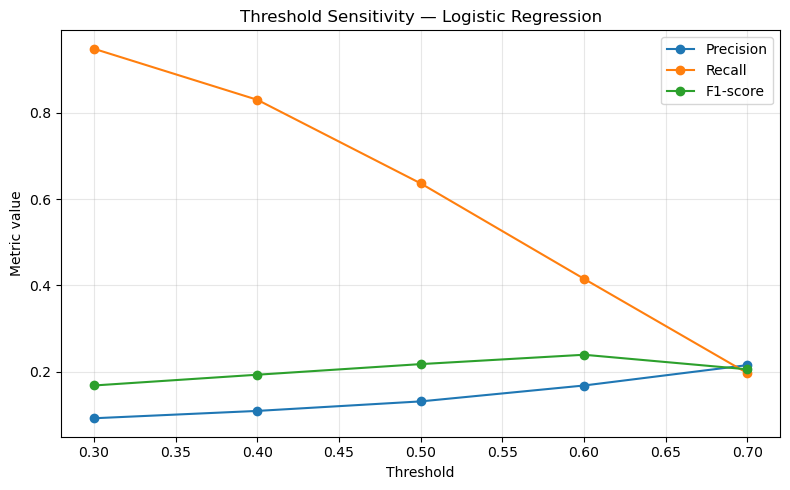

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], marker="o", label="F1-score")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Threshold Sensitivity — Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Logistic Regression threshold sensitivity result

The threshold sensitivity analysis shows that the default threshold of 0.5 leads to substantial overprediction of late orders, with a predicted positive rate far above the actual late-delivery rate.

Increasing the threshold improves precision and reduces the alert volume, but at the cost of lower recall.

Among the tested values, a threshold around **0.60** provides the best overall precision-recall balance in terms of F1-score, while **0.70** becomes more conservative and yields a predicted positive rate closer to the true class prevalence.

This confirms that Logistic Regression captures a meaningful signal, but also shows that its operational usefulness is highly sensitive to threshold choice. The model therefore remains a useful baseline rather than an obvious final candidate.

### Logistic Regression result summary

The Logistic Regression baseline captures a real predictive signal, but its default decision behavior is not operationally satisfactory.

At the default threshold of 0.5, the model achieves moderate recall but very low precision, largely because it overpredicts the positive class. This makes it useful as an interpretable baseline, but not yet as a strong operational classifier.

The threshold sensitivity analysis shows that performance can be partially improved by increasing the decision threshold, with a value around **0.60** providing the best overall precision-recall balance among the tested values.

Overall, Logistic Regression remains a relevant baseline model for interpretation and benchmarking, but the next step is to test a more flexible non-linear model.

## 10. Tree-Based Model — Random Forest

The next model is a Random Forest classifier.

This model is introduced to test whether a non-linear tree-based approach can better capture the structure of late-delivery risk than the Logistic Regression baseline.

Unlike Logistic Regression, Random Forest does not require feature scaling and can model more complex interactions between predictors.

In [32]:
# ============================================================
# 9. Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

In [33]:
numeric_transformer_rf = "passthrough"

categorical_transformer_rf = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, numerical_features),
        ("cat", categorical_transformer_rf, categorical_features)
    ]
)

print(preprocessor_rf)

ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['order_revenue', 'n_items', 'n_sellers',
                                  'n_categories', 'estimated_delivery_days',
                                  'purchase_month', 'purchase_dayofweek',
                                  'purchase_hour', 'is_weekend',
                                  'order_revenue_per_item']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['customer_state'])])


In [34]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [35]:
rf_pipeline.fit(X_train, y_train)
print("Random Forest model fitted successfully.")

Random Forest model fitted successfully.


In [36]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print("Predicted positive rate:", y_pred_rf.mean())

Predictions generated.
Predicted positive rate: 0.11086348087488339


In [37]:
rf_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_rf, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_rf),
    "pr_auc": average_precision_score(y_test, y_proba_rf)
}

rf_metrics_df = pd.DataFrame.from_dict(rf_metrics, orient="index", columns=["value"])
display(rf_metrics_df)

,value
accuracy,0.868353
precision,0.272090
recall,0.371885
f1_score,0.314255
roc_auc,0.757097
pr_auc,0.244374


In [38]:
print("Classification Report — Random Forest\n")
print(classification_report(y_test, y_pred_rf, digits=4, zero_division=0))

Classification Report — Random Forest

              precision    recall  f1-score   support

           0     0.9427    0.9122    0.9272     17729
           1     0.2721    0.3719    0.3143      1565

    accuracy                         0.8684     19294
   macro avg     0.6074    0.6420    0.6207     19294
weighted avg     0.8883    0.8684    0.8775     19294



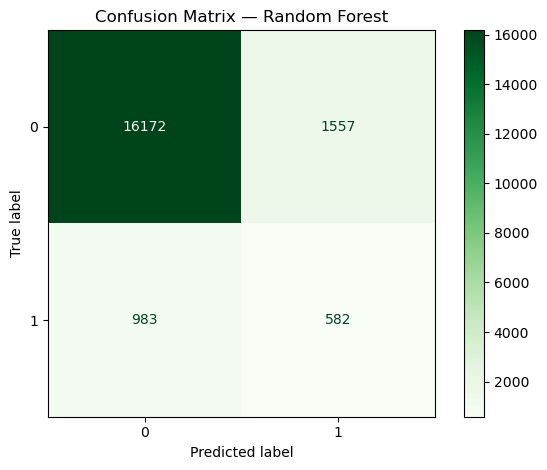

In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Greens")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

In [40]:
cm_rf_df = pd.DataFrame(
    cm_rf,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_rf_df)

,Predicted 0,Predicted 1
Actual 0,16172,1557
Actual 1,983,582


In [41]:
actual_positive_rate_rf = y_test.mean()
predicted_positive_rate_rf = y_pred_rf.mean()

comparison_rf_df = pd.DataFrame({
    "metric": ["actual_positive_rate", "predicted_positive_rate"],
    "value": [actual_positive_rate_rf, predicted_positive_rate_rf]
})

display(comparison_rf_df)

,metric,value
0,actual_positive_rate,0.081113
1,predicted_positive_rate,0.110863


In [42]:
# Recover transformed feature names
feature_names_num_rf = numerical_features

ohe_rf = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat_rf = ohe_rf.get_feature_names_out(categorical_features).tolist()

all_feature_names_rf = feature_names_num_rf + feature_names_cat_rf

importances = rf_pipeline.named_steps["classifier"].feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": all_feature_names_rf,
    "importance": importances
}).sort_values("importance", ascending=False)

display(rf_importance_df.head(20))

,feature,importance
4,estimated_delivery_days,0.242348
5,purchase_month,0.174927
9,order_revenue_per_item,0.138875
0,order_revenue,0.137803
7,purchase_hour,0.096501
6,purchase_dayofweek,0.052610
35,customer_state_SP,0.030050
28,customer_state_RJ,0.019738
20,customer_state_MG,0.013116
1,n_items,0.010480


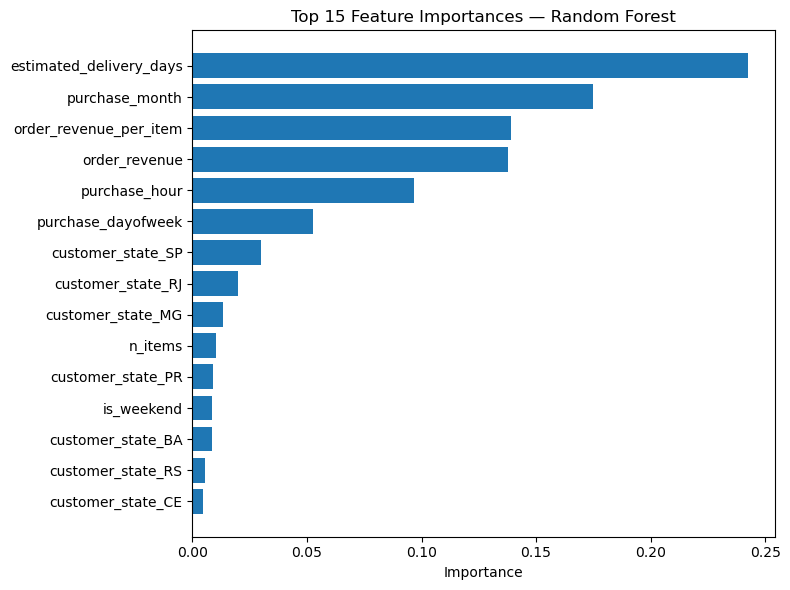

In [43]:
top_rf = rf_importance_df.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_rf["feature"], top_rf["importance"])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

### Random Forest result summary

The Random Forest model improves substantially over the Logistic Regression baseline.

Its main advantage is that it reduces the excessive positive overprediction observed with Logistic Regression while improving overall classification quality. In particular, it achieves higher precision, higher F1-score, higher ROC-AUC and higher PR-AUC, with a predicted positive rate much closer to the actual late-delivery prevalence.

This makes Random Forest a more credible operational candidate than the baseline model.

However, recall remains moderate, which means that a significant share of late deliveries is still missed. The model is therefore better balanced than Logistic Regression, but not yet fully satisfactory if the business objective is strong early-risk detection.

At this stage, Random Forest should be considered a strong non-linear benchmark rather than the final optimized model.

### Interim model comparison

At this stage, the comparison between the first two models is clear:

- Logistic Regression provides interpretability and a useful baseline, but its default decision behavior leads to excessive positive predictions and weak precision.
- Random Forest offers a much better overall balance, with stronger discrimination and a more realistic alert volume.

The next step is to test a boosting-based model in order to determine whether predictive performance can be improved further before any model-specific optimization is considered.

## 11. Boosting-Based Model — XGBoost

The third model is an XGBoost classifier.

This model is introduced as the boosting-based candidate of the comparison.  
It is expected to provide stronger predictive performance on structured tabular data by combining:

- non-linearity
- sequential error correction
- flexible interactions between features

The objective is to determine whether boosting improves late-delivery prediction beyond both the Logistic Regression baseline and the Random Forest benchmark.

In [45]:
# ============================================================
# 10. XGBoost
# ============================================================

from xgboost import XGBClassifier

In [46]:
numeric_transformer_xgb = "passthrough"

categorical_transformer_xgb = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_xgb, numerical_features),
        ("cat", categorical_transformer_xgb, categorical_features)
    ]
)

print(preprocessor_xgb)

ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['order_revenue', 'n_items', 'n_sellers',
                                  'n_categories', 'estimated_delivery_days',
                                  'purchase_month', 'purchase_dayofweek',
                                  'purchase_hour', 'is_weekend',
                                  'order_revenue_per_item']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['customer_state'])])


In [47]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight_value = negative_count / positive_count

print("Negative count:", negative_count)
print("Positive count:", positive_count)
print("scale_pos_weight:", scale_pos_weight_value)

Negative count: 70915
Positive count: 6261
scale_pos_weight: 11.326465420859288


In [48]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_xgb),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight_value,
        n_jobs=-1
    ))
])

xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [49]:
xgb_pipeline.fit(X_train, y_train)
print("XGBoost model fitted successfully.")

XGBoost model fitted successfully.


In [50]:
y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print("Predicted positive rate:", y_pred_xgb.mean())

Predictions generated.
Predicted positive rate: 0.29330361770498603


In [51]:
xgb_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "precision": precision_score(y_test, y_pred_xgb, zero_division=0),
    "recall": recall_score(y_test, y_pred_xgb, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_xgb, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_xgb),
    "pr_auc": average_precision_score(y_test, y_proba_xgb)
}

xgb_metrics_df = pd.DataFrame.from_dict(xgb_metrics, orient="index", columns=["value"])
display(xgb_metrics_df)

,value
accuracy,0.733181
precision,0.183425
recall,0.663259
f1_score,0.287375
roc_auc,0.766755
pr_auc,0.256167


In [52]:
print("Classification Report — XGBoost\n")
print(classification_report(y_test, y_pred_xgb, digits=4, zero_division=0))

Classification Report — XGBoost

              precision    recall  f1-score   support

           0     0.9613    0.7394    0.8359     17729
           1     0.1834    0.6633    0.2874      1565

    accuracy                         0.7332     19294
   macro avg     0.5724    0.7013    0.5616     19294
weighted avg     0.8982    0.7332    0.7914     19294



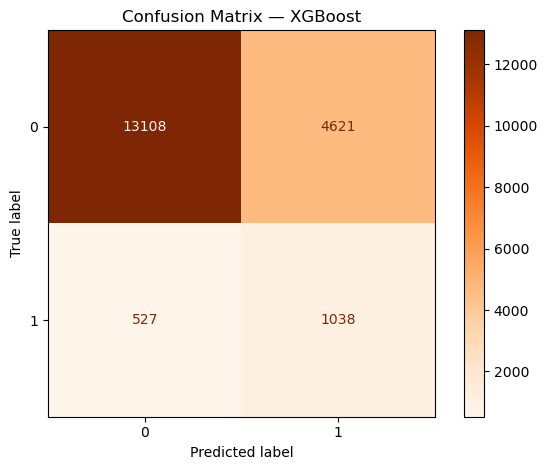

In [53]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot(cmap="Oranges")
plt.title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.show()

In [54]:
cm_xgb_df = pd.DataFrame(
    cm_xgb,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_xgb_df)

,Predicted 0,Predicted 1
Actual 0,13108,4621
Actual 1,527,1038


In [55]:
actual_positive_rate_xgb = y_test.mean()
predicted_positive_rate_xgb = y_pred_xgb.mean()

comparison_xgb_df = pd.DataFrame({
    "metric": ["actual_positive_rate", "predicted_positive_rate"],
    "value": [actual_positive_rate_xgb, predicted_positive_rate_xgb]
})

display(comparison_xgb_df)

,metric,value
0,actual_positive_rate,0.081113
1,predicted_positive_rate,0.293304


In [56]:
feature_names_num_xgb = numerical_features

ohe_xgb = xgb_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat_xgb = ohe_xgb.get_feature_names_out(categorical_features).tolist()

all_feature_names_xgb = feature_names_num_xgb + feature_names_cat_xgb

xgb_importances = xgb_pipeline.named_steps["classifier"].feature_importances_

xgb_importance_df = pd.DataFrame({
    "feature": all_feature_names_xgb,
    "importance": xgb_importances
}).sort_values("importance", ascending=False)

display(xgb_importance_df.head(20))

,feature,importance
35,customer_state_SP,0.094263
5,purchase_month,0.073232
28,customer_state_RJ,0.072854
27,customer_state_PR,0.062864
20,customer_state_MG,0.062231
14,customer_state_BA,0.057109
2,n_sellers,0.048148
4,estimated_delivery_days,0.046936
11,customer_state_AL,0.046008
19,customer_state_MA,0.033724


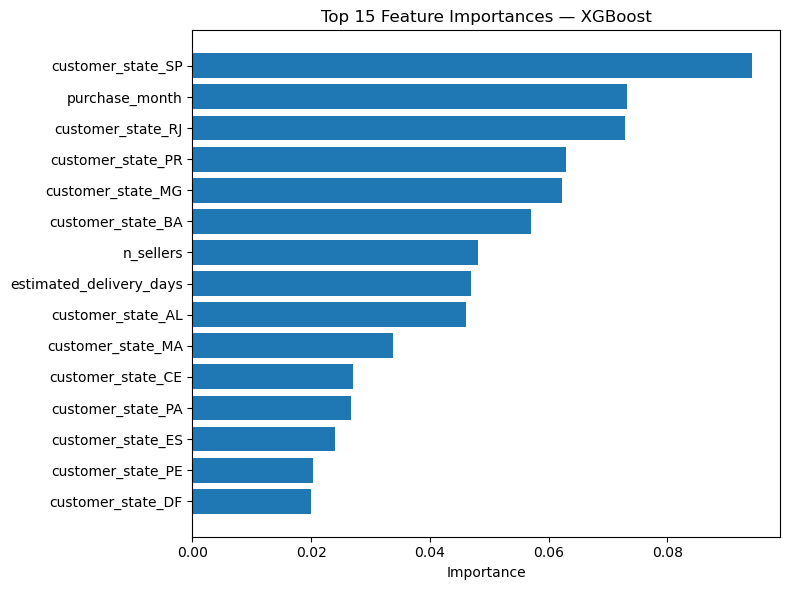

In [57]:
top_xgb = xgb_importance_df.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_xgb["feature"], top_xgb["importance"])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

### XGBoost result summary

The XGBoost model delivers the strongest overall discrimination performance among the tested models so far, with the highest ROC-AUC and PR-AUC.

It also achieves the highest recall on the positive class, which means it captures a larger share of late deliveries than the Random Forest benchmark. This suggests that boosting is better able to identify subtle risk patterns in the current feature set.

However, this gain comes at a cost:
- the predicted positive rate remains much higher than the actual late-delivery prevalence
- precision stays relatively low
- the alert volume would still be operationally heavy in a real intervention setting

This means that XGBoost appears to be the most promising model in terms of predictive capacity, but not yet the best calibrated operational classifier in its current default form.

At this stage, XGBoost should be considered the strongest candidate for targeted optimization rather than an immediately deployable final model.

## 12. Comparative Evaluation of the Tested Models

At this stage, three models have been tested:

- Logistic Regression
- Random Forest
- XGBoost

The objective of this section is to compare them on a common basis using:
- classification metrics
- class balance behavior
- operational alert volume

This section serves as an **intermediate model selection step**:
its purpose is to identify the most promising candidate for targeted optimization, while distinguishing between predictive potential and immediate operational usability.

It should not yet be interpreted as a definitive final model choice, since the tested models still rely on initial hyperparameter configurations rather than optimized settings.

In [58]:
comparison_models_df = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "accuracy": [
        lr_metrics["accuracy"],
        rf_metrics["accuracy"],
        xgb_metrics["accuracy"]
    ],
    "precision": [
        lr_metrics["precision"],
        rf_metrics["precision"],
        xgb_metrics["precision"]
    ],
    "recall": [
        lr_metrics["recall"],
        rf_metrics["recall"],
        xgb_metrics["recall"]
    ],
    "f1_score": [
        lr_metrics["f1_score"],
        rf_metrics["f1_score"],
        xgb_metrics["f1_score"]
    ],
    "roc_auc": [
        lr_metrics["roc_auc"],
        rf_metrics["roc_auc"],
        xgb_metrics["roc_auc"]
    ],
    "pr_auc": [
        lr_metrics["pr_auc"],
        rf_metrics["pr_auc"],
        xgb_metrics["pr_auc"]
    ],
    "predicted_positive_rate": [
        y_pred_lr.mean(),
        y_pred_rf.mean(),
        y_pred_xgb.mean()
    ]
})

display(comparison_models_df)

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,predicted_positive_rate
0,Logistic Regression,0.629107,0.131346,0.636422,0.217753,0.686273,0.162393,0.393024
1,Random Forest,0.868353,0.272090,0.371885,0.314255,0.757097,0.244374,0.110863
2,XGBoost,0.733181,0.183425,0.663259,0.287375,0.766755,0.256167,0.293304


In [59]:
comparison_models_rounded_df = comparison_models_df.copy()

metric_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate"
]

comparison_models_rounded_df[metric_cols] = comparison_models_rounded_df[metric_cols].round(4)

display(comparison_models_rounded_df)

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,predicted_positive_rate
0,Logistic Regression,0.6291,0.1313,0.6364,0.2178,0.6863,0.1624,0.3930
1,Random Forest,0.8684,0.2721,0.3719,0.3143,0.7571,0.2444,0.1109
2,XGBoost,0.7332,0.1834,0.6633,0.2874,0.7668,0.2562,0.2933


In [60]:
display(comparison_models_rounded_df.set_index("model").T)

model,Logistic Regression,Random Forest,XGBoost
accuracy,0.6291,0.8684,0.7332
precision,0.1313,0.2721,0.1834
recall,0.6364,0.3719,0.6633
f1_score,0.2178,0.3143,0.2874
roc_auc,0.6863,0.7571,0.7668
pr_auc,0.1624,0.2444,0.2562
predicted_positive_rate,0.3930,0.1109,0.2933


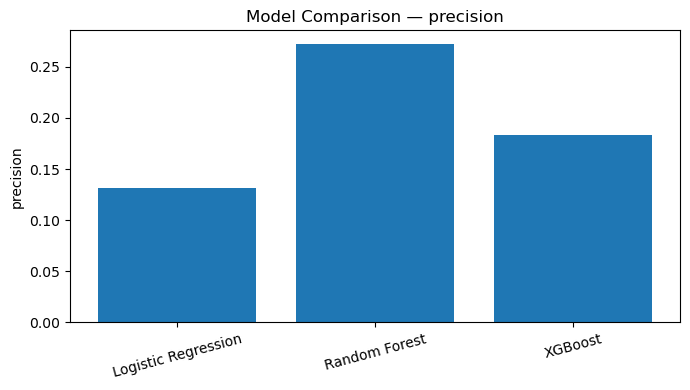

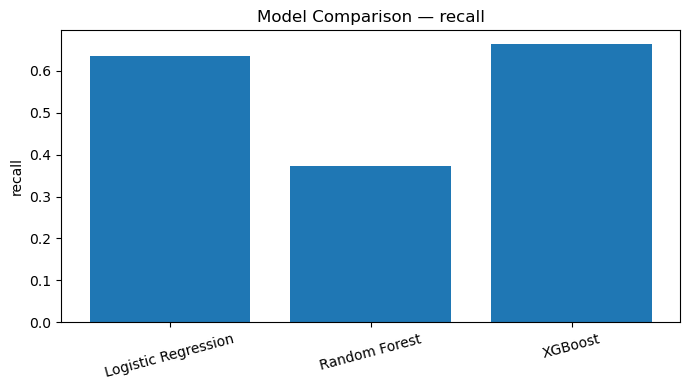

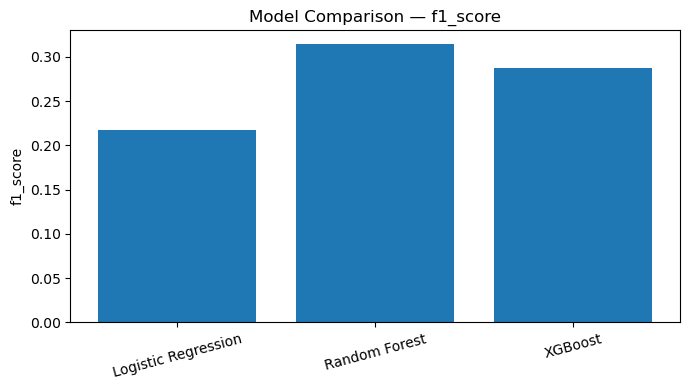

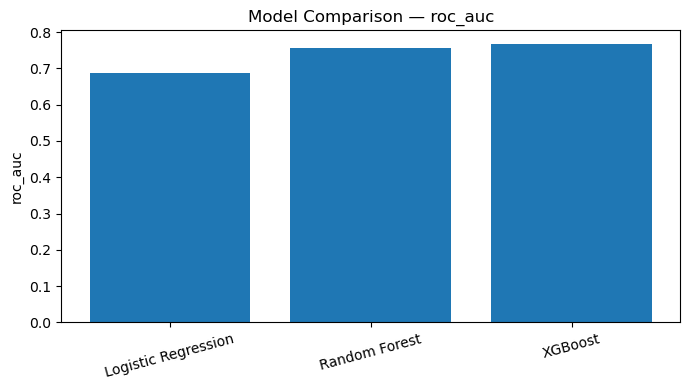

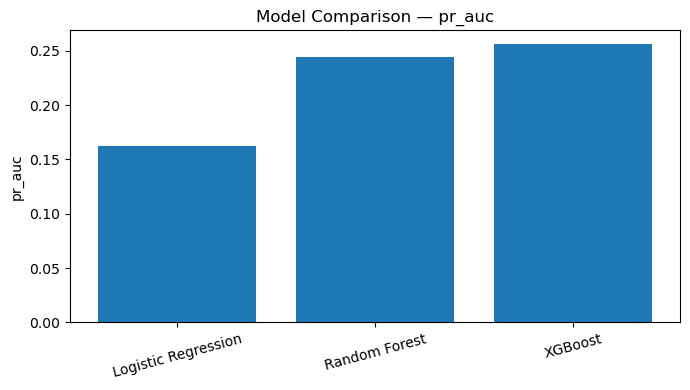

In [61]:
metrics_to_plot = ["precision", "recall", "f1_score", "roc_auc", "pr_auc"]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 4))
    plt.bar(comparison_models_rounded_df["model"], comparison_models_rounded_df[metric])
    plt.title(f"Model Comparison — {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

In [62]:
actual_rate = y_test.mean()

rate_comparison_df = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "predicted_positive_rate": [
        y_pred_lr.mean(),
        y_pred_rf.mean(),
        y_pred_xgb.mean()
    ]
})

rate_comparison_df["actual_positive_rate"] = actual_rate

display(rate_comparison_df.round(4))

,model,predicted_positive_rate,actual_positive_rate
0,Logistic Regression,0.3930,0.0811
1,Random Forest,0.1109,0.0811
2,XGBoost,0.2933,0.0811


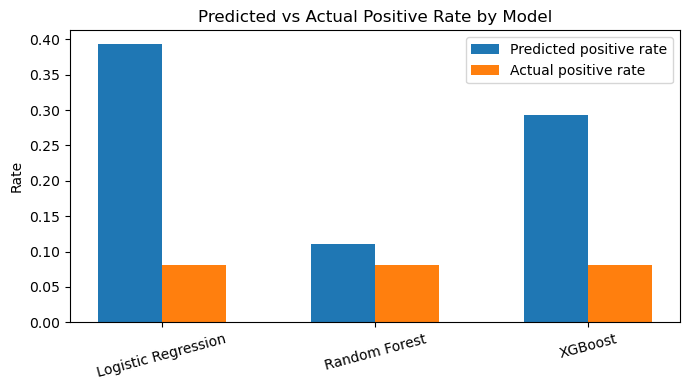

In [63]:
plt.figure(figsize=(7, 4))
x = np.arange(len(rate_comparison_df))

plt.bar(x - 0.15, rate_comparison_df["predicted_positive_rate"], width=0.3, label="Predicted positive rate")
plt.bar(x + 0.15, rate_comparison_df["actual_positive_rate"], width=0.3, label="Actual positive rate")

plt.xticks(x, rate_comparison_df["model"], rotation=15)
plt.ylabel("Rate")
plt.title("Predicted vs Actual Positive Rate by Model")
plt.legend()
plt.tight_layout()
plt.show()

### Comparative evaluation result

The three tested models show clearly differentiated behaviors.

**Logistic Regression** provides a useful interpretable baseline, but its default decision rule leads to a very high predicted positive rate and weak precision. Even after threshold sensitivity analysis, it remains primarily a benchmark model rather than a strong operational candidate.

**Random Forest** delivers the most balanced default operational behavior among the tested models. It substantially improves precision, F1-score, ROC-AUC and PR-AUC over Logistic Regression, while keeping the predicted positive rate much closer to the true late-delivery prevalence. This makes it the strongest candidate in terms of immediate operational usability.

**XGBoost** achieves the strongest overall discrimination performance, with the highest ROC-AUC, PR-AUC and recall. This suggests that it has the highest predictive potential among the tested models. However, its predicted positive rate remains substantially above the true class prevalence, and its precision is still relatively weak in its current untuned form.

Overall, the comparison shows a meaningful distinction between:
- **Random Forest**, which currently offers the best default operating balance
- **XGBoost**, which appears to offer the strongest predictive potential if further optimized

### Intermediate model selection

This section serves as an intermediate model selection step rather than a final definitive choice.

At the current stage:
- **Random Forest** is retained as the strongest benchmark in terms of immediate default balance between detection and alert volume
- **XGBoost** is retained as the most promising candidate for further optimization due to its stronger discrimination and recall performance

As a result, both models are selected as the two priority candidates for the next optimization step.

The next stage will therefore focus on targeted hyperparameter tuning and re-evaluation of these leading non-linear models.

## 13. Targeted Optimization — Random Forest

The next step is to perform a targeted hyperparameter search on the Random Forest model.

At this stage, the objective is not exhaustive tuning, but a controlled search over a limited set of plausible configurations.

Because the positive class is relatively rare, the optimization criterion is based on **average precision**, which is more informative than accuracy in this imbalanced classification setting.

In [64]:
from sklearn.model_selection import RandomizedSearchCV

In [65]:
rf_tuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

In [66]:
rf_param_dist = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [None, 8, 12, 16],
    "classifier__min_samples_split": [5, 10, 20],
    "classifier__min_samples_leaf": [1, 3, 5, 10],
    "classifier__max_features": ["sqrt", "log2", 0.6, 0.8]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_tuned_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [67]:
rf_random_search.fit(X_train, y_train)

print("Best RF params:")
print(rf_random_search.best_params_)

print("\nBest CV average precision:")
print(rf_random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF params:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 10, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None}

Best CV average precision:
0.24089869908886793


In [77]:
best_rf_model = rf_random_search.best_estimator_

In [78]:
y_pred_rf_tuned = best_rf_model.predict(X_test)
y_proba_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print("Predicted positive rate:", y_pred_rf_tuned.mean())

Predictions generated.
Predicted positive rate: 0.16248574686431014


In [79]:
rf_tuned_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_rf_tuned),
    "precision": precision_score(y_test, y_pred_rf_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_rf_tuned, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_rf_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_rf_tuned),
    "pr_auc": average_precision_score(y_test, y_proba_rf_tuned)
}

rf_tuned_metrics_df = pd.DataFrame.from_dict(rf_tuned_metrics, orient="index", columns=["value"])
display(rf_tuned_metrics_df)

,value
accuracy,0.834975
precision,0.241786
recall,0.484345
f1_score,0.322553
roc_auc,0.761744
pr_auc,0.245683


In [80]:
print("Classification Report — Tuned Random Forest\n")
print(classification_report(y_test, y_pred_rf_tuned, digits=4, zero_division=0))

Classification Report — Tuned Random Forest

              precision    recall  f1-score   support

           0     0.9501    0.8659    0.9060     17729
           1     0.2418    0.4843    0.3226      1565

    accuracy                         0.8350     19294
   macro avg     0.5959    0.6751    0.6143     19294
weighted avg     0.8926    0.8350    0.8587     19294



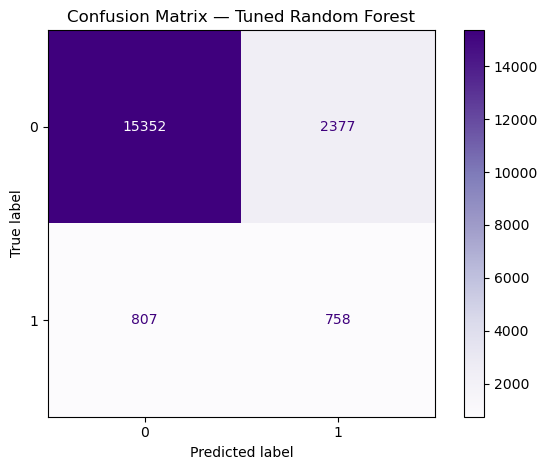

In [81]:
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned)
disp.plot(cmap="Purples")
plt.title("Confusion Matrix — Tuned Random Forest")
plt.tight_layout()
plt.show()

In [82]:
cm_rf_tuned_df = pd.DataFrame(
    cm_rf_tuned,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_rf_tuned_df)

,Predicted 0,Predicted 1
Actual 0,15352,2377
Actual 1,807,758


In [83]:
rf_compare_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"],
    "rf_baseline": [
        rf_metrics["accuracy"],
        rf_metrics["precision"],
        rf_metrics["recall"],
        rf_metrics["f1_score"],
        rf_metrics["roc_auc"],
        rf_metrics["pr_auc"]
    ],
    "rf_tuned": [
        rf_tuned_metrics["accuracy"],
        rf_tuned_metrics["precision"],
        rf_tuned_metrics["recall"],
        rf_tuned_metrics["f1_score"],
        rf_tuned_metrics["roc_auc"],
        rf_tuned_metrics["pr_auc"]
    ]
})

display(rf_compare_df)

,metric,rf_baseline,rf_tuned
0,accuracy,0.868353,0.834975
1,precision,0.272090,0.241786
2,recall,0.371885,0.484345
3,f1_score,0.314255,0.322553
4,roc_auc,0.757097,0.761744
5,pr_auc,0.244374,0.245683


In [84]:
rf_rate_compare_df = pd.DataFrame({
    "model": ["RF baseline", "RF tuned"],
    "predicted_positive_rate": [
        y_pred_rf.mean(),
        y_pred_rf_tuned.mean()
    ],
    "actual_positive_rate": [y_test.mean(), y_test.mean()]
})

display(rf_rate_compare_df)

,model,predicted_positive_rate,actual_positive_rate
0,RF baseline,0.110863,0.081113
1,RF tuned,0.162486,0.081113


### Tuned Random Forest result summary

The targeted Random Forest tuning leads to a modest but real shift in model behavior.

Compared with the baseline Random Forest, the tuned version improves recall and slightly increases F1-score, ROC-AUC and PR-AUC. This indicates a somewhat better ability to capture late deliveries.

However, these gains come with a cost:
- precision declines
- accuracy decreases
- the predicted positive rate moves further away from the true late-delivery prevalence

This means that the tuned Random Forest becomes more aggressive in flagging risk, but without generating a major overall performance improvement.

Overall, the tuning confirms that Random Forest is a strong benchmark model, but it does not appear to unlock a substantial additional performance margin in this problem setting.

## 14. Targeted Optimization — XGBoost

The next step is to perform a targeted hyperparameter search on the XGBoost model.

As with Random Forest, the objective is not exhaustive optimization, but a controlled search over a limited set of plausible configurations.

The search criterion remains **average precision**, which is appropriate for an imbalanced late-delivery classification problem.

In [68]:
from sklearn.model_selection import RandomizedSearchCV

In [69]:
xgb_tuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_xgb),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight_value,
        n_jobs=-1
    ))
])

In [70]:
xgb_param_dist = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__reg_lambda": [0.5, 1.0, 2.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuned_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [72]:
xgb_random_search.fit(X_train, y_train)

print("Best XGB params:")
print(xgb_random_search.best_params_)

print("\nBest CV average precision:")
print(xgb_random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGB params:
{'classifier__subsample': 1.0, 'classifier__reg_lambda': 0.5, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 5, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}

Best CV average precision:
0.24727519653121918


In [73]:
print("n_splits_:", xgb_random_search.n_splits_)
print("Number of candidates tested:", len(xgb_random_search.cv_results_["params"]))

n_splits_: 3
Number of candidates tested: 20


In [74]:
xgb_cv_results_df = pd.DataFrame(xgb_random_search.cv_results_)
xgb_cv_results_df = xgb_cv_results_df.sort_values("rank_test_score")

display(
    xgb_cv_results_df[
        ["rank_test_score", "mean_test_score", "std_test_score", "params"]
    ].head(10)
)

,rank_test_score,mean_test_score,std_test_score,params
14,1,0.247275,0.009505,"{'classifier__subsample': 1.0, 'classifier__re..."
8,2,0.247249,0.008410,"{'classifier__subsample': 0.7, 'classifier__re..."
10,3,0.247160,0.009967,"{'classifier__subsample': 0.8, 'classifier__re..."
19,4,0.246923,0.011182,"{'classifier__subsample': 0.8, 'classifier__re..."
7,5,0.245871,0.008933,"{'classifier__subsample': 1.0, 'classifier__re..."
1,6,0.245408,0.009917,"{'classifier__subsample': 0.7, 'classifier__re..."
17,7,0.245335,0.010959,"{'classifier__subsample': 0.7, 'classifier__re..."
5,8,0.245312,0.006646,"{'classifier__subsample': 0.7, 'classifier__re..."
16,9,0.245140,0.011480,"{'classifier__subsample': 0.7, 'classifier__re..."
9,10,0.245039,0.010416,"{'classifier__subsample': 0.7, 'classifier__re..."


In [85]:
best_xgb_model = xgb_random_search.best_estimator_

In [87]:
y_pred_xgb_tuned = best_xgb_model.predict(X_test)
y_proba_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print("Predicted positive rate:", y_pred_xgb_tuned.mean())

Predictions generated.
Predicted positive rate: 0.2757333886182233


In [88]:
xgb_tuned_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_xgb_tuned),
    "precision": precision_score(y_test, y_pred_xgb_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_xgb_tuned, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_xgb_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_xgb_tuned),
    "pr_auc": average_precision_score(y_test, y_proba_xgb_tuned)
}

xgb_tuned_metrics_df = pd.DataFrame.from_dict(xgb_tuned_metrics, orient="index", columns=["value"])
display(xgb_tuned_metrics_df)

,value
accuracy,0.748056
precision,0.190226
recall,0.646645
f1_score,0.293972
roc_auc,0.765741
pr_auc,0.256975


In [89]:
print("Classification Report — Tuned XGBoost\n")
print(classification_report(y_test, y_pred_xgb_tuned, digits=4, zero_division=0))

Classification Report — Tuned XGBoost

              precision    recall  f1-score   support

           0     0.9604    0.7570    0.8467     17729
           1     0.1902    0.6466    0.2940      1565

    accuracy                         0.7481     19294
   macro avg     0.5753    0.7018    0.5703     19294
weighted avg     0.8980    0.7481    0.8018     19294



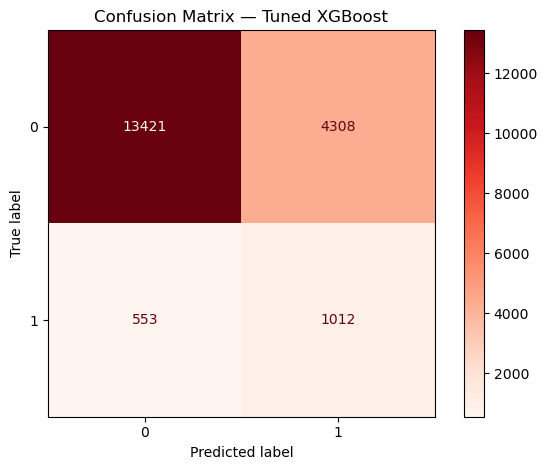

In [90]:
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_tuned)
disp.plot(cmap="Reds")
plt.title("Confusion Matrix — Tuned XGBoost")
plt.tight_layout()
plt.show()

In [91]:
cm_xgb_tuned_df = pd.DataFrame(
    cm_xgb_tuned,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_xgb_tuned_df)

,Predicted 0,Predicted 1
Actual 0,13421,4308
Actual 1,553,1012


In [92]:
xgb_compare_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"],
    "xgb_baseline": [
        xgb_metrics["accuracy"],
        xgb_metrics["precision"],
        xgb_metrics["recall"],
        xgb_metrics["f1_score"],
        xgb_metrics["roc_auc"],
        xgb_metrics["pr_auc"]
    ],
    "xgb_tuned": [
        xgb_tuned_metrics["accuracy"],
        xgb_tuned_metrics["precision"],
        xgb_tuned_metrics["recall"],
        xgb_tuned_metrics["f1_score"],
        xgb_tuned_metrics["roc_auc"],
        xgb_tuned_metrics["pr_auc"]
    ]
})

display(xgb_compare_df)

,metric,xgb_baseline,xgb_tuned
0,accuracy,0.733181,0.748056
1,precision,0.183425,0.190226
2,recall,0.663259,0.646645
3,f1_score,0.287375,0.293972
4,roc_auc,0.766755,0.765741
5,pr_auc,0.256167,0.256975


In [93]:
xgb_rate_compare_df = pd.DataFrame({
    "model": ["XGB baseline", "XGB tuned"],
    "predicted_positive_rate": [
        y_pred_xgb.mean(),
        y_pred_xgb_tuned.mean()
    ],
    "actual_positive_rate": [y_test.mean(), y_test.mean()]
})

display(xgb_rate_compare_df)

,model,predicted_positive_rate,actual_positive_rate
0,XGB baseline,0.293304,0.081113
1,XGB tuned,0.275733,0.081113


## 15. Final Comparative Conclusion and Model Retention

The full modeling sequence leads to three main conclusions.

First, **Logistic Regression** remains useful as an interpretable baseline, but not as the preferred predictive model for this use case.

Second, **Random Forest** provides the most balanced default operational behavior, with a predicted positive rate closer to the true late-delivery prevalence and a stronger precision/F1 balance than the linear baseline.

Third, **XGBoost** delivers the strongest overall predictive potential across the tested models, especially in terms of discrimination and minority-class detection. After tuning, its gains remain moderate, but it still retains the strongest upside for further operating-point adjustment.

Overall, the results suggest that:
- **Random Forest** is the strongest conservative benchmark
- **Tuned XGBoost** is the preferred model for final threshold analysis and operational calibration

This means that the main remaining lever is no longer model family selection, but **decision-threshold tuning** and, in a later iteration, **targeted feature enrichment**.

### Retained model for operating-threshold analysis

Based on the comparative evaluation and targeted optimization steps, **Tuned XGBoost** is retained as the final candidate for threshold calibration.

This choice is motivated by:
- the strongest overall discrimination capacity
- the highest minority-class detection potential
- better suitability for ranking late-delivery risk cases before deciding the operational cutoff

The next step is therefore to evaluate multiple decision thresholds in order to identify a more appropriate balance between recall, precision, and alert volume.

## 16. Threshold Tuning — Tuned XGBoost

The default classification threshold of 0.5 is not necessarily optimal in an imbalanced operational setting.

In this use case, the decision threshold directly affects:
- how many orders are flagged as risky
- how many late deliveries are successfully detected
- how much false-alert volume is generated

The objective of this section is therefore to test several plausible thresholds and identify a more relevant operating point for business use.

In [94]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results_xgb = []

for thr in thresholds:
    y_pred_thr = (y_proba_xgb_tuned >= thr).astype(int)

    threshold_results_xgb.append({
        "threshold": thr,
        "accuracy": accuracy_score(y_test, y_pred_thr),
        "precision": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall": recall_score(y_test, y_pred_thr, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_thr, zero_division=0),
        "predicted_positive_rate": y_pred_thr.mean()
    })

threshold_xgb_df = pd.DataFrame(threshold_results_xgb)
display(threshold_xgb_df)

,threshold,accuracy,precision,recall,f1_score,predicted_positive_rate
0,0.3,0.447289,0.116691,0.884984,0.206193,0.615165
1,0.4,0.629678,0.149497,0.760383,0.249869,0.412563
2,0.5,0.748056,0.190226,0.646645,0.293972,0.275733
3,0.6,0.818959,0.228909,0.520128,0.317907,0.184306
4,0.7,0.875350,0.288945,0.367412,0.323488,0.103141


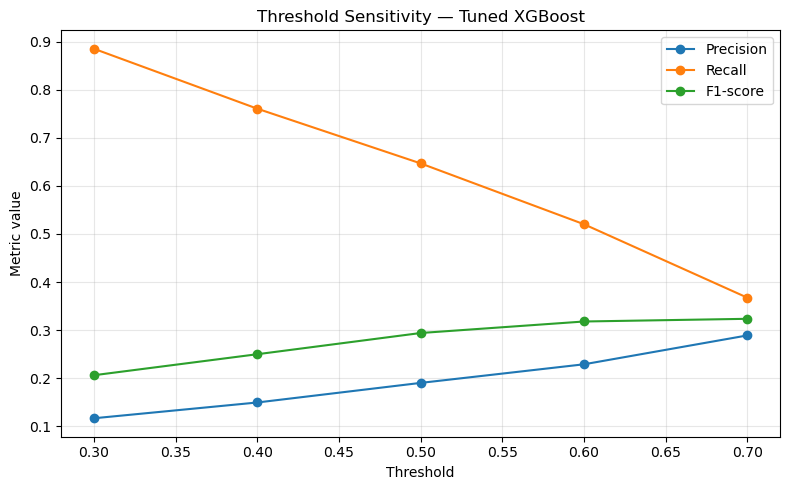

In [95]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_xgb_df["threshold"], threshold_xgb_df["precision"], marker="o", label="Precision")
plt.plot(threshold_xgb_df["threshold"], threshold_xgb_df["recall"], marker="o", label="Recall")
plt.plot(threshold_xgb_df["threshold"], threshold_xgb_df["f1_score"], marker="o", label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Threshold Sensitivity — Tuned XGBoost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [96]:
threshold_volume_df = threshold_xgb_df[["threshold", "predicted_positive_rate"]].copy()
threshold_volume_df["actual_positive_rate"] = y_test.mean()

display(threshold_volume_df)

,threshold,predicted_positive_rate,actual_positive_rate
0,0.3,0.615165,0.081113
1,0.4,0.412563,0.081113
2,0.5,0.275733,0.081113
3,0.6,0.184306,0.081113
4,0.7,0.103141,0.081113


In [97]:
best_f1_row = threshold_xgb_df.sort_values("f1_score", ascending=False).head(1)
display(best_f1_row)

,threshold,accuracy,precision,recall,f1_score,predicted_positive_rate
4,0.7,0.87535,0.288945,0.367412,0.323488,0.103141


In [98]:
display(threshold_xgb_df[threshold_xgb_df["predicted_positive_rate"] <= 0.20])

,threshold,accuracy,precision,recall,f1_score,predicted_positive_rate
3,0.6,0.818959,0.228909,0.520128,0.317907,0.184306
4,0.7,0.875350,0.288945,0.367412,0.323488,0.103141


### Threshold tuning result

The threshold analysis shows that the default 0.5 cutoff is not the most relevant operating point for this use case.

Lower thresholds increase recall, but they also generate a very large alert volume and weak precision. In practice, this would create too many false positives for an operational prioritization workflow.

Higher thresholds reduce alert volume and improve precision, at the cost of lower recall.

Among the tested values, **0.7** provides the strongest overall balance:
- it delivers the highest F1-score
- it substantially improves precision
- it brings the predicted positive rate much closer to the true late-delivery prevalence

By contrast, **0.6** remains a plausible alternative if the business objective is to prioritize recall more aggressively, but it generates a materially larger alert volume.

Overall, the threshold analysis confirms that **operating-point calibration is more important than additional model-family changes at this stage**.

## 17. Final Recommendation

Based on the full modeling process, the recommended configuration is:

- **Model:** Tuned XGBoost
- **Operating threshold:** 0.7

This recommendation is based on three considerations:

1. **Predictive potential**  
   Tuned XGBoost retains the strongest overall discrimination capacity among the tested models.

2. **Operational usability**  
   A threshold of 0.7 produces a more realistic alert volume and a better precision/recall balance than the default 0.5 threshold.

3. **Business fit**  
   In a prioritization setting, the objective is not to label as many orders as possible as risky, but to identify a narrower and more actionable subset of orders with elevated late-delivery risk.

This final result should therefore be interpreted as a **risk-ranking and prioritization tool**, not as a perfect late-delivery classifier.

This recommendation should remain interpreted with caution: even at the retained threshold, precision remains moderate, which means the model is more suitable for **risk prioritization and investigative focus** than for high-confidence automated decision-making.

## 18. Data Science Extension — Final Conclusion

This Data Science extension successfully moves the project from descriptive and diagnostic analytics toward predictive decision support.

Starting from the business question of late-delivery risk, the workflow established:
- an order-level modeling dataset aligned with the target definition
- leakage-aware feature selection
- comparison across linear, bagging, and boosting classifiers
- targeted hyperparameter tuning on the leading non-linear candidates
- final operating-threshold calibration on the retained model

The results show that late-delivery prediction is feasible, but performance remains moderate and constrained by the current ex-ante feature set. In its current form, the model is better interpreted as a prioritization aid than as a high-precision standalone classifier. This means that the main next levers are:
- richer ex-ante feature engineering
- better operational calibration
- and, in a future engineering layer, reproducible model serving

Overall, the predictive layer is already strong enough to function as a credible extension of the Revenue Intelligence project:
it demonstrates how a business-driven analytics workflow can evolve from **monitoring exposure** to **anticipating execution risk**.